## Q1 
 Perform an effective discharge analysis of Valley Creek near Stanley, Idaho using the record
 from USGS gage 13295000. Use the complete water years since 1921, the methods recom
mended by USACE, and the bedload transport data from Emmett and Wolman (2001) to
 complete the analysis. Provide your results in tabular and graphical form. Clearly specify
 the computed effective discharge ($m^3/s$) and bedload yield ($metric\ tons/(yr * km^2)$).

Effective Discharge (m³/s): 22.52
Bedload Yield (metric tons/(yr km²)): 19.3


,Discharge_bin,Mean_Discharge_m3s,Total_Bedload_tons,Count
0,"(0.0, 1.0]",0.987043,11.564211,7
1,"(1.0, 2.0]",1.763694,25233.453633,3944
2,"(2.0, 3.0]",2.453568,171367.694125,12564
3,"(3.0, 4.0]",3.405628,112221.495049,3895
4,"(4.0, 5.0]",4.446455,77373.600195,1461
5,"(5.0, 6.0]",5.455352,72672.971051,859
6,"(6.0, 7.0]",6.470789,93002.280404,743
7,"(7.0, 8.0]",7.495215,108544.700236,619
8,"(8.0, 9.0]",8.505118,135011.292703,576
9,"(9.0, 10.0]",9.482880,149584.554654,497


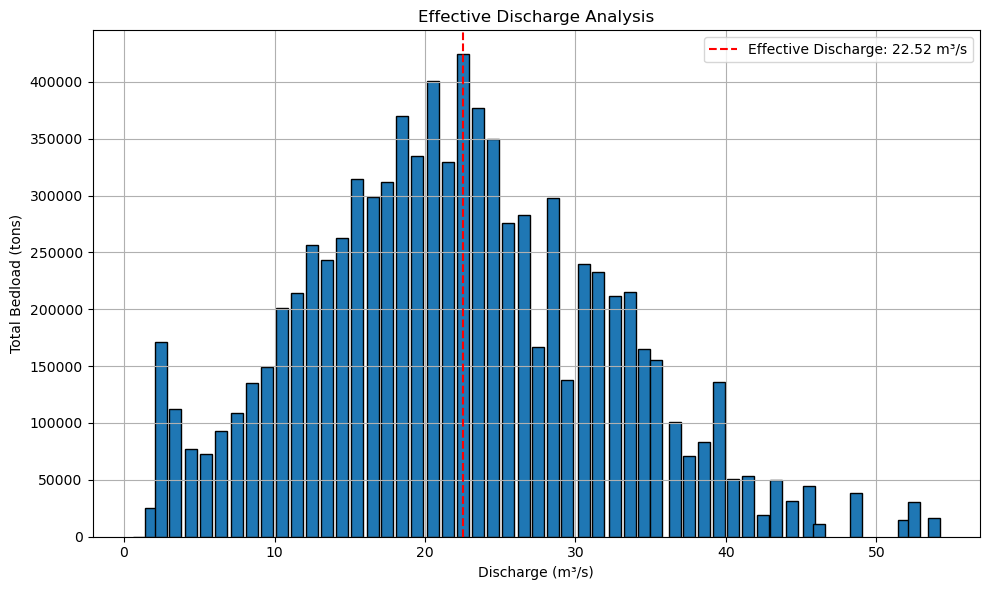

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load Excel data
excel_path = r"C:\Users\adunw\OneDrive - Colostate\Fort Collins\Courses\Spring 2025\CIVE 613 - River Restoration\HW 3\HW 3.xlsx"
bedload_data = pd.read_excel(excel_path, sheet_name="Q1 bedload data")
flow_data = pd.read_excel(excel_path, sheet_name="Q1 Flow Data")

# Convert discharge from cfs to m3/s
flow_data['Discharge (m3/s)'] = flow_data['Discharge (cfs)'] * 0.0283168

# Extract required parameters
coef = bedload_data['Coefficient'].iloc[0]
exp = bedload_data['Exponent'].iloc[0]
bedload_yield_annual = bedload_data['Bedload Yield (tons year-1)'].iloc[0]

# Bedload transport function
def bedload_transport(Q):
    return coef * Q ** exp

# Calculate bedload transport for each flow
discharges = flow_data['Discharge (m3/s)']
flow_data['Bedload (tons/day)'] = bedload_transport(discharges) * 86400 / 1000  # Convert from kg/s to tons/day

# Bin discharge data
flow_data['Discharge_bin'] = pd.cut(flow_data['Discharge (m3/s)'], bins=np.arange(0, flow_data['Discharge (m3/s)'].max() + 1, 1))

# Calculate frequency and bedload yield by bin
bin_summary = flow_data.groupby('Discharge_bin').agg({
    'Discharge (m3/s)': 'mean',
    'Bedload (tons/day)': ['sum', 'count']
}).reset_index()

bin_summary.columns = ['Discharge_bin', 'Mean_Discharge_m3s', 'Total_Bedload_tons', 'Count']

# Compute effective discharge (maximum bedload yield)
effective_discharge_row = bin_summary.loc[bin_summary['Total_Bedload_tons'].idxmax()]
effective_discharge = effective_discharge_row['Mean_Discharge_m3s']

# Bedload yield (metric tons/(yr km²))
watershed_area_km2 = 381  
bedload_yield_metric_ton_yr_km2 = bedload_yield_annual / watershed_area_km2

# Results
print("Effective Discharge (m³/s):", effective_discharge.round(2))
print("Bedload Yield (metric tons/(yr km²)):", bedload_yield_metric_ton_yr_km2)

# Tabular Results
display(bin_summary[['Discharge_bin', 'Mean_Discharge_m3s', 'Total_Bedload_tons', 'Count']])

# Graphical Results
plt.figure(figsize=(10, 6))
plt.bar(bin_summary['Mean_Discharge_m3s'], bin_summary['Total_Bedload_tons'], width=0.8, align='center', edgecolor='black')
plt.xlabel('Discharge (m³/s)')
plt.ylabel('Total Bedload (tons)')
plt.title('Effective Discharge Analysis')
plt.axvline(effective_discharge, color='red', linestyle='--', label=f'Effective Discharge: {effective_discharge:.2f} m³/s')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Q2
A number of studies have suggested a close correspondence among bankfull discharge, effective discharge, and peak flows with return periods from approximately 1.2-1.8 years (e.g.,Andrews, 1980; Andrews and Nankervis, 1995; and Emmett and Wolman, 2001. However, the classic study by Williams, 1978 and other studies have suggested weak correspondence at best. 
 
**1. Explain in less than approximately 300 words why you think there is correspondence among bankfull discharge, effective discharge, and peak flows with return periods from approximately 1.2-1.8 years in some minimally disturbed watersheds but not in others.**

In minimally disturbed watersheds, bankfull discharge may align with effective discharge and the 1.2–1.8‐year peak flows because the channel has adjusted over time to the dominant flood events. In these systems, the discharge that just fills the channel to its banks is the primary agent of sediment transport and channel shaping. The recurrent nature of these bankfull events ensures that the channel geometry, sediment transport, and floodplain connectivity are in a dynamic equilibrium, so that a flood with a return period of roughly 1.2–1.8 years typically represents the threshold discharge that drives long‐term geomorphic change.

However, variations in catchment characteristics—such as differences in sediment supply, soil cohesion, channel confinement, and/or basin hydrology—result in a mismatch between the bankfull and effective discharges. Watersheds that have experienced significant anthropogenic or natural disturbances may exhibit altered channel morphologies or sediment regimes that decouple bankfull discharge from the flood events responsible for channel maintenance. For instance, urbanization or changes in land use can modify runoff patterns, leading to more frequent or higher magnitude flows that no longer reflect the historic bankfull condition. Similarly, a watershed burned by wildfire often experiences decreases in infiltration and increases in overland flow, which can lead to incision and a decoupling of the bankfull and effective discharges. 


**2. Summarize what Soar and Thorne (2001) say in section 5.75 about the relationship between bankfull and effective discharge in sand-bed rivers.**

Soar and Thorne (2001) describe the relationship between bankfull and effective discharge in sand‐bed rivers by noting that although the bankfull stage is often assumed to correspond to the effective discharge, this equivalence does not universally hold. Their analysis of cumulative sediment load distributions indicates that bankfull discharge typically exceeds effective discharge - in about 86 percent of the studied sites, the ratio Qb/Qe is greater than one, implying that bankfull discharge generally represents an upper limit to effective discharge.

The authors explain that the bankfull stage is marked by a distinct discontinuity in the sediment rating curve due to factors such as changes in bank slope, increased resistance over the floodplain, and shifts in momentum between in-bank and over-bank flows. In contrast, the effective discharge is identified at the peak of the sediment load histogram, corresponding to the steepest segment of the cumulative sediment curve. Because of these differing control points, the effective discharge is typically a moderately high in-bank flow, not necessarily coinciding with the bankfull stage.

Soar and Thorne also illustrate that variability in flow regimes significantly affects the Qb/Qe ratio. High flow variability can decouple bankfull discharge from the effective discharge, as channels may reflect past high-magnitude events rather than a consistent modal condition. In sand‐bed rivers, the effective discharge tends to fall between the mean annual discharge and bankfull discharge, with the 2-year flow event acting as an approximate upper boundary for bankfull conditions.

**3. Briefly describe situations in which you might not be comfortable using daily streamflow data like Andrews, Emmett, and Wolman. For those situations, indicate how you think using streamflow with hourly or sub-hourly resolution would affect estimates of sediment transport capacity and yield (i.e., decrease or increase)**

In systems with highly variable or “flashy” flow regimes—such as urban streams, small mountainous catchments, or rivers subject to dam releases—the temporal resolution of daily data may be insufficient. Daily averages can smooth out the high-magnitude, short-duration flows that are often the primary drivers of sediment transport. In these cases, the daily data may underestimate the peaks that contribute disproportionately to sediment mobilization.

Using streamflow data with hourly or sub-hourly resolution would likely increase estimates of sediment transport capacity and yield. Because sediment transport is a nonlinear function of discharge, even brief periods of high flow can result in significantly higher sediment movement. Incorporating finer temporal resolution data would enable better estimation of these events, leading to increased and more realistic estimates of sediment transport capacity and overall yield in smaller, flashier streams.
